# Encoding Categorical Data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/01-data-preprocessing/02_encoding_categorical.ipynb)

**Time**: ~20 minutes

## What You'll Learn
- Why ML models can't handle text
- Label Encoding vs One-Hot Encoding
- When to use which encoding
- Handle high-cardinality categories

## Why This Matters

ML models only understand numbers, not text.

**Example:** Product categories
```
Category: ['Electronics', 'Clothing', 'Food']
```

Can't multiply "Electronics" × 5.2 or find average of "Clothing"!

**Solution:** Convert to numbers:
```
Label Encoding:  [0, 1, 2]
One-Hot:        [[1,0,0], [0,1,0], [0,0,1]]
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

np.random.seed(42)
print("Encoding Categorical Data: Making Text ML-Ready")

Encoding Categorical Data: Making Text ML-Ready


---
## 1. Create Sample Dataset

In [2]:
# E-commerce dataset
data = {
    'product_id': range(1, 16),
    'category': ['Electronics', 'Clothing', 'Food', 'Electronics', 'Home',
                 'Clothing', 'Food', 'Electronics', 'Home', 'Clothing',
                 'Electronics', 'Food', 'Home', 'Clothing', 'Electronics'],
    'size': ['Small', 'Medium', 'Large', 'Medium', 'Small',
             'Large', 'Medium', 'Small', 'Large', 'Medium',
             'Small', 'Large', 'Medium', 'Small', 'Large'],
    'color': ['Red', 'Blue', 'Green', 'Red', 'Blue',
              'Green', 'Red', 'Blue', 'Green', 'Red',
              'Blue', 'Green', 'Red', 'Blue', 'Green'],
    'price': [299, 49, 19, 399, 89,
              59, 15, 499, 129, 39,
              349, 25, 99, 45, 599]
}

df = pd.DataFrame(data)
print("E-commerce Product Dataset:")
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"\nCategorical columns: {df.select_dtypes(include='object').columns.tolist()}")

E-commerce Product Dataset:
   product_id     category    size  color  price
0           1  Electronics   Small    Red    299
1           2     Clothing  Medium   Blue     49
2           3         Food   Large  Green     19
3           4  Electronics  Medium    Red    399
4           5         Home   Small   Blue     89
5           6     Clothing   Large  Green     59
6           7         Food  Medium    Red     15
7           8  Electronics   Small   Blue    499
8           9         Home   Large  Green    129
9          10     Clothing  Medium    Red     39

Shape: (15, 5)

Categorical columns: ['category', 'size', 'color']


---
## 2. Identify Categorical Variables

In [3]:
# Check data types
print("Data Types:")
print(df.dtypes)

print("\n" + "="*50)
print("Unique Values per Column:")
print("="*50)
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique values → {df[col].unique()}")

Data Types:
product_id     int64
category      object
size          object
color         object
price          int64
dtype: object

Unique Values per Column:
category: 4 unique values → ['Electronics' 'Clothing' 'Food' 'Home']
size: 3 unique values → ['Small' 'Medium' 'Large']
color: 3 unique values → ['Red' 'Blue' 'Green']


---
## 3. Label Encoding (Ordinal)

In [4]:
# Label Encoding: Converts categories to numbers 0, 1, 2...
# ⚠️ Implies ORDER: Small(0) < Medium(1) < Large(2)

df_label = df.copy()
label_encoder = LabelEncoder()

# Encode 'size' (has natural order)
df_label['size_encoded'] = label_encoder.fit_transform(df_label['size'])

print("Label Encoding for 'size':")
print(df_label[['size', 'size_encoded']].head(10))

print("\nMapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} → {i}")

print("\n✅ USE Label Encoding when:")
print("  - Categories have ORDER (Low/Med/High, Small/Large)")
print("  - Tree-based models (Random Forest, XGBoost)")
print("\n❌ DON'T USE when:")
print("  - No order (Red/Blue/Green)")
print("  - Linear models (they'll think 2 > 1 > 0)")

Label Encoding for 'size':
     size  size_encoded
0   Small             2
1  Medium             1
2   Large             0
3  Medium             1
4   Small             2
5   Large             0
6  Medium             1
7   Small             2
8   Large             0
9  Medium             1

Mapping:
  Large → 0
  Medium → 1
  Small → 2

✅ USE Label Encoding when:
  - Categories have ORDER (Low/Med/High, Small/Large)
  - Tree-based models (Random Forest, XGBoost)

❌ DON'T USE when:
  - No order (Red/Blue/Green)
  - Linear models (they'll think 2 > 1 > 0)


---
## 4. One-Hot Encoding (Nominal)

In [5]:
# One-Hot Encoding: Creates separate binary column for each category
# No order implied!

df_onehot = df.copy()

# Encode 'color' (no natural order)
onehot_encoded = pd.get_dummies(df_onehot['color'], prefix='color')

# Combine with original dataframe
df_onehot = pd.concat([df_onehot, onehot_encoded], axis=1)

print("One-Hot Encoding for 'color':")
print(df_onehot[['color', 'color_Blue', 'color_Green', 'color_Red']].head(10))

print("\n✅ USE One-Hot when:")
print("  - NO order (colors, countries, brands)")
print("  - Linear models (Logistic Regression, Neural Networks)")
print("\n❌ DON'T USE when:")
print("  - Too many categories (>50) → creates too many columns")
print("  - Tree-based models (Label Encoding works fine)")

One-Hot Encoding for 'color':
   color  color_Blue  color_Green  color_Red
0    Red       False        False       True
1   Blue        True        False      False
2  Green       False         True      False
3    Red       False        False       True
4   Blue        True        False      False
5  Green       False         True      False
6    Red       False        False       True
7   Blue        True        False      False
8  Green       False         True      False
9    Red       False        False       True

✅ USE One-Hot when:
  - NO order (colors, countries, brands)
  - Linear models (Logistic Regression, Neural Networks)

❌ DON'T USE when:
  - Too many categories (>50) → creates too many columns
  - Tree-based models (Label Encoding works fine)


---
## 5. Encoding Multiple Columns

In [6]:
# Encode multiple categorical columns at once
df_multi = df.copy()

# One-hot encode 'category' and 'color'
df_multi_encoded = pd.get_dummies(df_multi, columns=['category', 'color'], drop_first=True)

print("Encoded Dataset (multiple columns):")
print(df_multi_encoded.head())
print(f"\nOriginal shape: {df.shape}")
print(f"After encoding: {df_multi_encoded.shape}")
print(f"New columns: {df_multi_encoded.shape[1] - df.shape[1]}")

print("\n⚡ drop_first=True avoids 'dummy variable trap'")
print("   (if Blue=0 and Green=0, then must be Red!)")

Encoded Dataset (multiple columns):
   product_id    size  price  category_Electronics  category_Food  \
0           1   Small    299                  True          False   
1           2  Medium     49                 False          False   
2           3   Large     19                 False           True   
3           4  Medium    399                  True          False   
4           5   Small     89                 False          False   

   category_Home  color_Green  color_Red  
0          False        False       True  
1          False        False      False  
2          False         True      False  
3          False        False       True  
4           True        False      False  

Original shape: (15, 5)
After encoding: (15, 8)
New columns: 3

⚡ drop_first=True avoids 'dummy variable trap'
   (if Blue=0 and Green=0, then must be Red!)


---
## 6. Scikit-Learn ColumnTransformer

In [7]:
# Professional way: ColumnTransformer
# Keeps code clean, works in pipelines

from sklearn.preprocessing import OneHotEncoder

df_transform = df.copy()

# Define transformer
ct = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first'), ['category', 'color', 'size'])
    ],
    remainder='passthrough'  # Keep other columns unchanged
)

# Transform
X_transformed = ct.fit_transform(df_transform)

print("ColumnTransformer Result:")
print(f"Shape: {X_transformed.shape}")
print(f"\nFirst 3 rows:")
print(X_transformed[:3])

print("\n✅ This is how you encode in production pipelines!")

ColumnTransformer Result:
Shape: (15, 9)

First 3 rows:
[[  1.   0.   0.   0.   1.   0.   1.   1. 299.]
 [  0.   0.   0.   0.   0.   1.   0.   2.  49.]
 [  0.   1.   0.   1.   0.   0.   0.   3.  19.]]

✅ This is how you encode in production pipelines!


---
## 7. Handle High Cardinality

In [8]:
# Problem: What if 'category' has 100+ values?
# One-hot creates 100+ columns!

# Solution 1: Group rare categories
df_high = df.copy()

# Count frequencies
category_counts = df_high['category'].value_counts()
print("Category frequencies:")
print(category_counts)

# Group categories with <3 occurrences as 'Other'
threshold = 3
rare_categories = category_counts[category_counts < threshold].index
df_high['category_grouped'] = df_high['category'].apply(
    lambda x: 'Other' if x in rare_categories else x
)

print("\nAfter grouping:")
print(df_high['category_grouped'].value_counts())

print("\n✅ Reduces columns")
print("✅ Prevents overfitting on rare categories")

Category frequencies:
category
Electronics    5
Clothing       4
Food           3
Home           3
Name: count, dtype: int64

After grouping:
category_grouped
Electronics    5
Clothing       4
Food           3
Home           3
Name: count, dtype: int64

✅ Reduces columns
✅ Prevents overfitting on rare categories


In [9]:
# Solution 2: Target Encoding (advanced)
# Replace category with AVERAGE of target variable

# Example: Average price per category
df_target = df.copy()
target_means = df_target.groupby('category')['price'].mean()

print("Target Encoding (average price per category):")
print(target_means)

df_target['category_encoded'] = df_target['category'].map(target_means)

print("\nOriginal vs Encoded:")
print(df_target[['category', 'price', 'category_encoded']].head(10))

print("\n✅ Works with 1000+ categories")
print("✅ Only creates 1 column")
print("⚠️ Risk of overfitting (use with cross-validation)")

Target Encoding (average price per category):
category
Clothing        48.000000
Electronics    429.000000
Food            19.666667
Home           105.666667
Name: price, dtype: float64

Original vs Encoded:
      category  price  category_encoded
0  Electronics    299        429.000000
1     Clothing     49         48.000000
2         Food     19         19.666667
3  Electronics    399        429.000000
4         Home     89        105.666667
5     Clothing     59         48.000000
6         Food     15         19.666667
7  Electronics    499        429.000000
8         Home    129        105.666667
9     Clothing     39         48.000000

✅ Works with 1000+ categories
✅ Only creates 1 column
⚠️ Risk of overfitting (use with cross-validation)


---
## 8. Visualize Impact

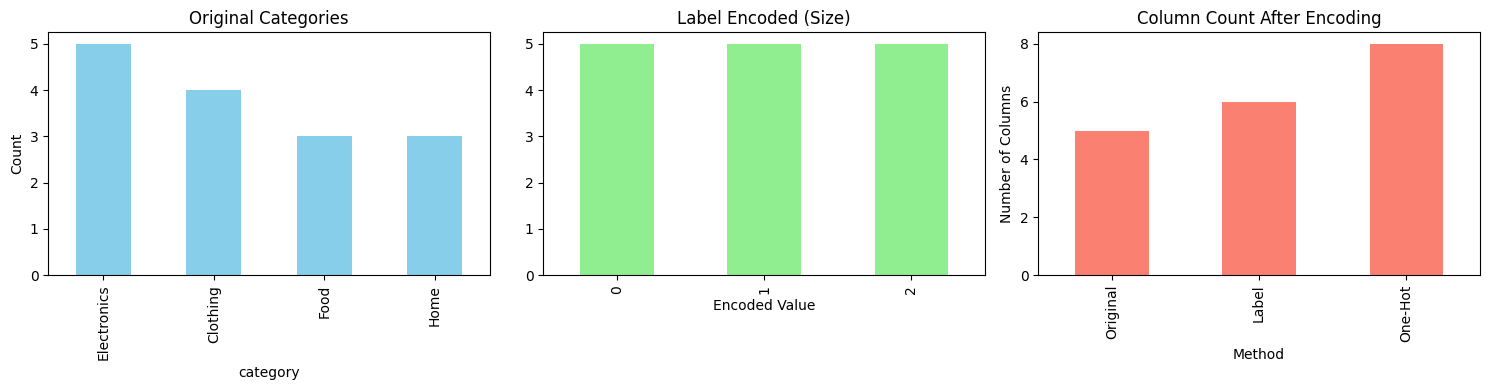

One-Hot creates MORE columns (but needed for linear models)


In [10]:
# Compare encoding methods
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original
df['category'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Original Categories')
axes[0].set_ylabel('Count')

# Label Encoded
df_label['size_encoded'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Label Encoded (Size)')
axes[1].set_xlabel('Encoded Value')

# One-Hot (show column count)
encoding_comparison = pd.DataFrame({
    'Method': ['Original', 'Label', 'One-Hot'],
    'Columns': [len(df.columns), 
                len(df_label.columns),
                len(df_onehot.columns)]
})
encoding_comparison.plot(x='Method', y='Columns', kind='bar', ax=axes[2], color='salmon', legend=False)
axes[2].set_title('Column Count After Encoding')
axes[2].set_ylabel('Number of Columns')

plt.tight_layout()
plt.show()

print("One-Hot creates MORE columns (but needed for linear models)")

---
## Decision Tree: Which Encoding?

```
Does category have ORDER?
  YES (Low/Med/High, Small/Large)
    → Label Encoding
  
  NO (Colors, Countries, Brands)
    ↓
    How many unique values?
      < 50
        → One-Hot Encoding
      
      50-1000
        → Group rare + One-Hot
      
      > 1000
        → Target Encoding or Hashing
```

---
## Model-Specific Guide

| Model Type | Recommended Encoding |
|------------|---------------------|
| Linear Regression | One-Hot |
| Logistic Regression | One-Hot |
| Neural Networks | One-Hot |
| Random Forest | Label (faster) |
| XGBoost | Label (faster) |
| Decision Trees | Label |
| SVM | One-Hot |
| Naive Bayes | Label or One-Hot |

**Why?**
- Tree models split on single values → Label is fine
- Linear models multiply weights → Need One-Hot

---
## Key Takeaways

1. **ML models need numbers**, not text
2. **Label Encoding** for ordinal (has order)
3. **One-Hot Encoding** for nominal (no order)
4. **drop_first=True** avoids multicollinearity
5. **Group rare categories** if >50 unique values
6. **Use ColumnTransformer** for production code

**Most common mistake**: Label encoding nominal data (e.g., Red=0, Blue=1) → model thinks Blue > Red!

---
## Your Turn

1. Load a dataset with categorical variables
2. Identify ordinal vs nominal categories
3. Apply appropriate encoding
4. Check column count before/after

In [11]:
# Your code here